In [1]:
#Common Model Algorithms
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier

#Common Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

#Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
# from pandas.tools.plotting import scatter_matrix


In [2]:


import numpy as np
import tensorflow as tf
import pandas as pd
import random
import keras
from tqdm import tqdm


import math
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from scipy.stats import chi2_contingency, ttest_ind
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier)
import xgboost as xgb
import pprint
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score



In [3]:

#Configure Visualization Defaults
#%matplotlib inline = show plots in Jupyter Notebook browser
%matplotlib inline
mpl.style.use('ggplot')
sns.set_style('white')
pylab.rcParams['figure.figsize'] = 12,8
pd.set_option('max_columns', None)

train_csv = "level_02_data/train.csv"
test_csv = "level_02_data/test.csv"
SS_csv = "level_02_data/sample_lvl_2.csv"

X = pd.read_csv(train_csv)
test_data = pd.read_csv(test_csv)
ss = pd.read_csv(SS_csv)



In [4]:
X.head()

,ids,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,oxygen,standard_ph,standard_temperature,38100,57500,55800,59300,29600,33400,25400,19400,50390,37880,17300,49700,34500,30400
0,0,0.203596,0.232044,1.663324,0.841600,4.446809,2.973241,0.403047,3.546433,2.362222,0.000000,1.026990,1.459533,0.189460,5.343706,23.722053,0.662303,0,1,1,1,0,0,1,1,1,1,0,1,1,0
1,1,0.247856,0.097036,3.188038,0.707709,4.157477,2.740956,0.460625,2.955361,3.098499,0.699283,0.851321,0.776347,0.315767,3.645319,23.421773,3.253074,0,0,1,1,1,0,1,0,1,1,1,1,1,0
2,2,0.637343,0.147664,2.217765,0.937237,3.805827,2.833870,0.230313,3.704052,2.055440,0.815830,1.189147,1.469885,0.399972,3.479622,23.421773,2.863484,0,0,1,0,0,0,0,1,0,0,0,1,0,0
3,3,0.230152,0.307985,1.524714,0.473400,4.019488,1.904732,0.633360,2.521908,1.411198,0.427340,0.891860,0.703888,0.315767,3.811015,23.121494,2.532333,0,0,1,1,0,0,0,1,0,1,0,1,0,0
4,4,0.239004,0.156102,2.668249,0.583382,4.504675,3.094029,0.287891,3.585838,2.300866,0.427340,0.810782,1.366372,0.189460,5.343706,24.622890,0.759700,0,0,1,1,1,0,0,1,1,0,0,1,0,0


In [5]:
X.columns

Index(['ids', 'bod', 'ammonium', 'silicon_dixoide', 'potassium_dichromate',
       'oxygen_saturation', 'conduct', 'nitrogen_dioxide', 'hardness',
       'nitrate', 'carbon_dioxide', 'potassium_permanganate', 'chlorine',
       'phosphate', 'oxygen', 'standard_ph', 'standard_temperature', '38100',
       '57500', '55800', '59300', '29600', '33400', '25400', '19400', '50390',
       '37880', '17300', '49700', '34500', '30400'],
      dtype='object')

In [6]:
Categorical_cols = []

Continious_cols = ['bod', 'ammonium', 'silicon_dixoide', 'potassium_dichromate',
       'oxygen_saturation', 'conduct', 'nitrogen_dioxide', 'hardness',
       'nitrate', 'carbon_dioxide', 'potassium_permanganate', 'chlorine',
       'phosphate', 'oxygen', 'standard_ph', 'standard_temperature']

Non_numerical_cols = []

Target_col = ['38100', '57500', '55800', '59300', '29600', '33400', '25400', '19400', '50390','37880', '17300', '49700', '34500','30400']

In [7]:

for var in Target_col: 
    print(X[var].value_counts())

0    545
1    197
Name: 38100, dtype: int64
0    504
1    238
Name: 57500, dtype: int64
0    429
1    313
Name: 55800, dtype: int64
0    453
1    289
Name: 59300, dtype: int64
0    554
1    188
Name: 29600, dtype: int64
0    598
1    144
Name: 33400, dtype: int64
0    411
1    331
Name: 25400, dtype: int64
1    403
0    339
Name: 19400, dtype: int64
0    503
1    239
Name: 50390, dtype: int64
0    526
1    216
Name: 37880, dtype: int64
0    375
1    367
Name: 17300, dtype: int64
1    443
0    299
Name: 49700, dtype: int64
0    546
1    196
Name: 34500, dtype: int64
0    522
1    220
Name: 30400, dtype: int64


In [8]:
#check if null
print(X.isnull().sum() )
print("\n\n",test_data.isnull().sum())


ids                       0
bod                       0
ammonium                  0
silicon_dixoide           0
potassium_dichromate      0
oxygen_saturation         0
conduct                   0
nitrogen_dioxide          0
hardness                  0
nitrate                   0
carbon_dioxide            0
potassium_permanganate    0
chlorine                  0
phosphate                 0
oxygen                    0
standard_ph               0
standard_temperature      0
38100                     0
57500                     0
55800                     0
59300                     0
29600                     0
33400                     0
25400                     0
19400                     0
50390                     0
37880                     0
17300                     0
49700                     0
34500                     0
30400                     0
dtype: int64


 ids                       0
bod                       0
ammonium                  0
silicon_dixoide           0
pota

In [9]:
#check null values
print(X[X.columns[X.isnull().any()]].isnull().sum())
print("\nTEST DATA\n",test_data[test_data.columns[test_data.isnull().any()]].isnull().sum())

Series([], dtype: float64)

TEST DATA
 Series([], dtype: float64)


In [10]:

numerical = [var for var in X.columns if X[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 31 numerical variables

The numerical variables are : ['ids', 'bod', 'ammonium', 'silicon_dixoide', 'potassium_dichromate', 'oxygen_saturation', 'conduct', 'nitrogen_dioxide', 'hardness', 'nitrate', 'carbon_dioxide', 'potassium_permanganate', 'chlorine', 'phosphate', 'oxygen', 'standard_ph', 'standard_temperature', '38100', '57500', '55800', '59300', '29600', '33400', '25400', '19400', '50390', '37880', '17300', '49700', '34500', '30400']


In [11]:
X[numerical].head()


,ids,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,oxygen,standard_ph,standard_temperature,38100,57500,55800,59300,29600,33400,25400,19400,50390,37880,17300,49700,34500,30400
0,0,0.203596,0.232044,1.663324,0.841600,4.446809,2.973241,0.403047,3.546433,2.362222,0.000000,1.026990,1.459533,0.189460,5.343706,23.722053,0.662303,0,1,1,1,0,0,1,1,1,1,0,1,1,0
1,1,0.247856,0.097036,3.188038,0.707709,4.157477,2.740956,0.460625,2.955361,3.098499,0.699283,0.851321,0.776347,0.315767,3.645319,23.421773,3.253074,0,0,1,1,1,0,1,0,1,1,1,1,1,0
2,2,0.637343,0.147664,2.217765,0.937237,3.805827,2.833870,0.230313,3.704052,2.055440,0.815830,1.189147,1.469885,0.399972,3.479622,23.421773,2.863484,0,0,1,0,0,0,0,1,0,0,0,1,0,0
3,3,0.230152,0.307985,1.524714,0.473400,4.019488,1.904732,0.633360,2.521908,1.411198,0.427340,0.891860,0.703888,0.315767,3.811015,23.121494,2.532333,0,0,1,1,0,0,0,1,0,1,0,1,0,0
4,4,0.239004,0.156102,2.668249,0.583382,4.504675,3.094029,0.287891,3.585838,2.300866,0.427340,0.810782,1.366372,0.189460,5.343706,24.622890,0.759700,0,0,1,1,1,0,0,1,1,0,0,1,0,0


In [12]:
X.describe()

,ids,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,oxygen,standard_ph,standard_temperature,38100,57500,55800,59300,29600,33400,25400,19400,50390,37880,17300,49700,34500,30400
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.00000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,370.500000,0.331126,0.257841,1.211066,0.539669,4.507710,3.086641,0.442157,4.046853,1.577984,0.404878,0.577145,0.605677,0.261551,4.344838,24.135240,2.506238,0.265499,0.320755,0.421833,0.389488,0.253369,0.19407,0.446092,0.543127,0.322102,0.291105,0.494609,0.597035,0.264151,0.296496
std,214.341239,0.485623,0.922358,0.952293,0.801212,1.006646,1.055296,0.885325,1.053550,1.114336,1.031535,0.939577,0.685594,0.520911,1.002372,0.968226,1.052183,0.441896,0.467082,0.494185,0.487963,0.435234,0.39575,0.497421,0.498473,0.467597,0.454578,0.500308,0.490825,0.441177,0.457020
min,0.000000,0.026556,0.012657,0.069305,0.066945,0.048964,0.966303,0.000000,1.694407,0.000000,0.000000,0.013513,0.072459,0.000000,0.041424,21.019540,0.155836,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,185.250000,0.115076,0.046409,0.554441,0.200836,4.149687,2.415758,0.057578,3.388814,0.920346,0.000000,0.256748,0.248431,0.042102,3.893863,23.421773,1.684976,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,370.500000,0.185892,0.084379,0.970272,0.339509,4.544736,2.954658,0.172734,3.940481,1.411198,0.000000,0.351339,0.362295,0.105256,4.473800,24.322611,2.415456,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,555.750000,0.334162,0.139226,1.524714,0.626418,4.966493,3.605055,0.403047,4.689172,2.055440,0.427340,0.608086,0.732354,0.273665,4.970889,24.622890,3.272554,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,741.000000,6.160982,17.086844,6.618643,14.967098,10.580645,12.422572,8.751880,9.930012,18.805741,9.556867,19.107427,6.562724,7.262651,8.491936,27.925961,4.986748,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
# def plot_f(col):
#     city_count  = X[col].value_counts()
# #     city_count = city_count[:10,]
#     plt.figure(figsize=(10,5))
#     sns.barplot(city_count.index, city_count.values, alpha=0.8)
#     plt.ylabel('Number of Occurrences', fontsize=12)
#     plt.xlabel(col, fontsize=24)
#     plt.show()
    
# def plot_cont(col):
#     plt.figure(figsize=(10,5))
#     plt.xlabel(col, fontsize=24)
#     plt.ylabel('Number of Occurrences', fontsize=12)
#     sns.distplot(X[col],bins=100,kde=False)
#     plt.show()
    
# for i in range(len(Categorical_cols)):
#     plot_f(Target_col[i])
    
# for i in range(len(Continious_cols)):
#     plot_f(Continious_cols[i])

###### PLOTTING TAKES LONG, COMMENT WHEN DONE

In [14]:
X.head(3)

,ids,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,oxygen,standard_ph,standard_temperature,38100,57500,55800,59300,29600,33400,25400,19400,50390,37880,17300,49700,34500,30400
0,0,0.203596,0.232044,1.663324,0.841600,4.446809,2.973241,0.403047,3.546433,2.362222,0.000000,1.026990,1.459533,0.189460,5.343706,23.722053,0.662303,0,1,1,1,0,0,1,1,1,1,0,1,1,0
1,1,0.247856,0.097036,3.188038,0.707709,4.157477,2.740956,0.460625,2.955361,3.098499,0.699283,0.851321,0.776347,0.315767,3.645319,23.421773,3.253074,0,0,1,1,1,0,1,0,1,1,1,1,1,0
2,2,0.637343,0.147664,2.217765,0.937237,3.805827,2.833870,0.230313,3.704052,2.055440,0.815830,1.189147,1.469885,0.399972,3.479622,23.421773,2.863484,0,0,1,0,0,0,0,1,0,0,0,1,0,0


In [15]:
del X['ids']
del test_data['ids']
y = X[Target_col]
X.drop(Target_col,axis=1, inplace=True)


In [16]:
X.head(3)

,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,oxygen,standard_ph,standard_temperature
0,0.203596,0.232044,1.663324,0.841600,4.446809,2.973241,0.403047,3.546433,2.362222,0.000000,1.026990,1.459533,0.189460,5.343706,23.722053,0.662303
1,0.247856,0.097036,3.188038,0.707709,4.157477,2.740956,0.460625,2.955361,3.098499,0.699283,0.851321,0.776347,0.315767,3.645319,23.421773,3.253074
2,0.637343,0.147664,2.217765,0.937237,3.805827,2.833870,0.230313,3.704052,2.055440,0.815830,1.189147,1.469885,0.399972,3.479622,23.421773,2.863484


In [17]:
y.head(5)

,38100,57500,55800,59300,29600,33400,25400,19400,50390,37880,17300,49700,34500,30400
0,0,1,1,1,0,0,1,1,1,1,0,1,1,0
1,0,0,1,1,1,0,1,0,1,1,1,1,1,0
2,0,0,1,0,0,0,0,1,0,0,0,1,0,0
3,0,0,1,1,0,0,0,1,0,1,0,1,0,0
4,0,0,1,1,1,0,0,1,1,0,0,1,0,0


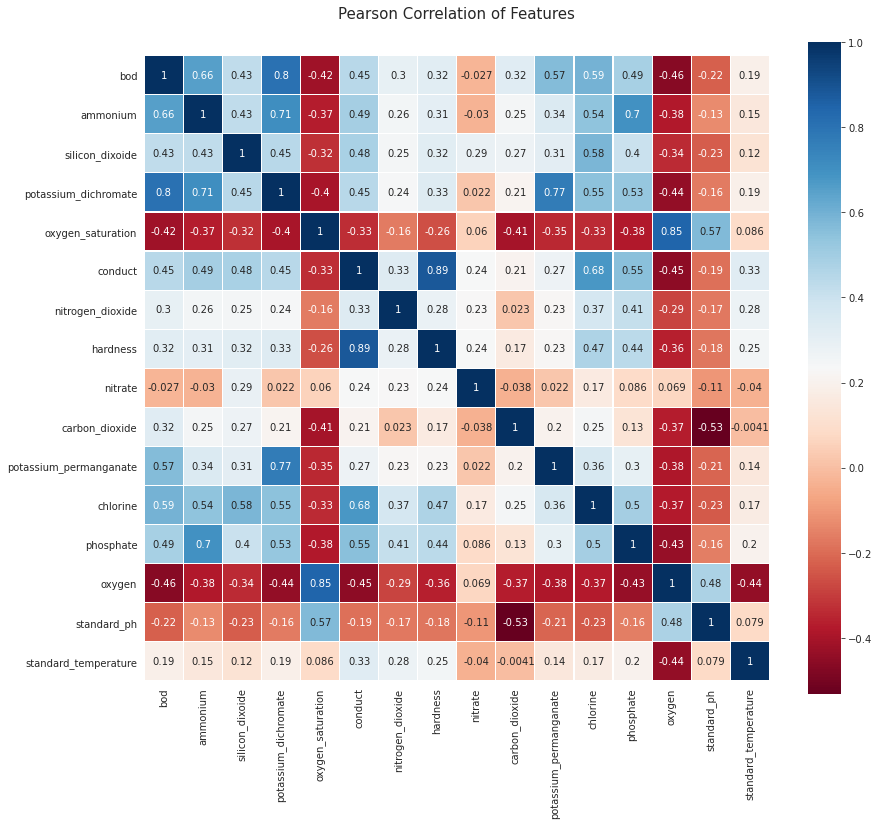

In [18]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

In [19]:
X.drop(['oxygen'],axis=1, inplace=True)
test_data.drop(['oxygen'],axis=1, inplace=True)

test_data

,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,standard_ph,standard_temperature
0,0.132780,0.042190,0.207915,0.167364,5.946883,2.452924,0.057578,3.310004,0.092035,0.000000,0.324313,0.217377,0.042102,25.223448,4.694556
1,0.097372,0.160321,6.480033,1.047219,2.608438,1.914024,0.575782,2.049050,1.533910,7.536716,1.337790,1.211102,0.357870,21.620099,3.662143
2,0.247856,0.282671,0.519789,0.540346,2.457095,4.032458,0.921250,5.004411,1.871371,1.787056,0.432417,2.059909,0.399972,22.821215,2.727128
3,0.141632,0.067504,0.623746,0.129109,4.758397,2.239222,0.000000,3.231194,1.196450,0.000000,0.216209,0.207026,0.021051,24.022332,1.168769
4,0.265560,0.029533,1.940545,0.506873,4.393393,3.233399,0.115156,4.649768,1.012381,0.000000,0.472956,0.496862,1.157814,24.622890,2.863484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,0.115076,0.029533,0.346526,0.105200,4.874129,1.700322,0.057578,2.364289,0.705599,0.000000,0.162156,0.134567,0.021051,24.923169,2.279100
314,0.159336,0.168759,3.430606,0.750746,4.326625,2.294970,0.172734,2.915956,2.024762,0.271943,0.378365,0.362295,0.252614,23.421773,1.733674
315,0.203596,0.071723,0.485136,0.349073,4.170830,4.171829,0.172734,3.231194,1.104415,0.000000,0.581060,0.817753,0.063153,24.322611,0.545426
316,0.150484,0.029533,1.247493,0.191273,4.691628,2.871036,0.057578,4.334529,0.981703,3.418716,0.256748,0.227729,0.021051,22.220657,2.103785


In [20]:
ss_lst = ['bod', 'ammonium', 'silicon_dixoide', 'potassium_dichromate',
       'oxygen_saturation', 'conduct', 'nitrogen_dioxide', 'hardness',
       'nitrate', 'carbon_dioxide', 'potassium_permanganate', 'chlorine',
       'phosphate', 'standard_ph', 'standard_temperature']

std_sc = StandardScaler()
std_sc.fit(X[ss_lst])

X_temp = X.copy()
test_data_temp = test_data.copy()

X_temp[ss_lst] = std_sc.transform(X[ss_lst])
test_data_temp[ss_lst] = std_sc.transform(test_data[ss_lst])

X = X_temp
test_data = test_data_temp

In [21]:
X

,bod,ammonium,silicon_dixoide,potassium_dichromate,oxygen_saturation,conduct,nitrogen_dioxide,hardness,nitrate,carbon_dioxide,potassium_permanganate,chlorine,phosphate,standard_ph,standard_temperature
0,-0.262789,-0.027988,0.475235,0.377098,-0.060541,-0.107530,-0.044205,-0.475305,0.704246,-0.392765,0.479097,1.246267,-0.138486,-0.427035,-1.753667
1,-0.171587,-0.174458,2.077411,0.209874,-0.348156,-0.327792,0.020875,-1.036712,1.365423,0.285597,0.292005,0.249107,0.104151,-0.737377,0.710275
2,0.630990,-0.119532,1.057845,0.496543,-0.697720,-0.239687,-0.239445,-0.325596,0.428755,0.398657,0.651798,1.261376,0.265909,-0.737377,0.339758
3,-0.208068,0.054402,0.329583,-0.082767,-0.485327,-1.120733,0.216115,-1.448411,-0.149775,0.021789,0.335180,0.143347,0.104151,-1.047719,0.024818
4,-0.189828,-0.110377,1.531215,0.054595,-0.003017,0.007006,-0.174365,-0.437878,0.649148,0.021789,0.248830,1.110291,-0.138486,0.503993,-1.661038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,-0.353991,-0.215653,0.766540,-0.518742,0.470442,0.861620,-0.499765,1.059209,-0.783403,-0.392765,-0.413190,0.611711,-0.421562,-0.116692,-1.327572
738,-0.536395,-0.192767,1.494802,-0.309713,-0.480902,1.769098,-0.369605,0.385520,-0.507912,-0.392765,-0.211706,0.490843,-0.462002,0.193650,1.191948
739,-0.518155,-0.201921,1.094258,-0.393324,0.107604,0.720653,-0.434685,0.946928,-1.279286,-0.392765,-0.010222,0.505951,-0.421562,0.193650,0.506491
740,-0.408712,-0.243116,1.604041,-0.196240,0.479292,1.134745,-0.434685,0.909500,-0.838501,-0.392765,-0.355623,0.883663,-0.381123,0.814335,-0.308648


In [22]:
X_ = X.values
y_ = y.values
test_data_OHE = test_data.values

In [23]:
print(y.shape[0])
y.sum(axis=0)/742

742


38100    0.265499
57500    0.320755
55800    0.421833
59300    0.389488
29600    0.253369
33400    0.194070
25400    0.446092
19400    0.543127
50390    0.322102
37880    0.291105
17300    0.494609
49700    0.597035
34500    0.264151
30400    0.296496
dtype: float64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=3, random_state=42, shuffle=True)


In [25]:
def get_accuracy(y_pred, y):
    return accuracy_score(y_pred, y)

def get_majority(y, col):
    # print(y, col)
    if y[col].value_counts()[0]>y[col].value_counts()[1]:
        return 0 , 1
    return 1 , 0

def balance_classes(X, y, col):
    comb = pd.concat([X, y], axis=1)
    print(comb.shape)

    factor = max(comb[col].value_counts())
    # print(comb[col])

    maj, mino = get_majority(comb, col)
    df_majority = comb[comb[col]==maj]
    df_minority = comb[comb[col]==mino]
    #     Upsample minority class
    df_minority_upsampled = resample(df_minority, 
                                        replace = True,     # sample with replacement
                                        n_samples = factor,    # to match majority class
                                        random_state = 123) # reproducible results

    comb =  pd.concat([df_majority, df_minority_upsampled])
    print(comb.shape)

    y = comb[col]
    comb.drop(Target_col, axis=1, inplace=True)

    return comb, y

col = Target_col[0]
X_train_OHE, y_train_temp = balance_classes(X_train, y_train, col)



(739, 29)
(1086, 29)


In [26]:
# X_train_OHE = X_train.values
X_test_OHE = X_test.values

In [28]:
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

def run_model(MODEL):
    avg_val_accuracy = []
    for col in tqdm(Target_col):

        X_train_OHE, y_train_temp = balance_classes(X_train, y_train, col)
        print(X_train_OHE.shape, y_train_temp.shape)

        X_train_OHE = X_train_OHE.values
        y_train_temp = y_train_temp.values
        y_test_temp = y_test[col].values

        print(X_train_OHE.shape, y_train_temp.shape)
        MODEL.fit(X_train_OHE, y_train_temp)

        pred_train = MODEL.predict(X_train_OHE)
        print( "\nTrain acc = ",get_accuracy(y_train_temp, pred_train) )

        pred_val = MODEL.predict(X_test_OHE)
        print( "Validation acc = ",get_accuracy(y_test_temp, pred_val) )
        
        avg_val_accuracy.append(get_accuracy(y_test_temp, pred_val)) 
        # pred_test = RFC.predict(test_data_OHE)
        ss[col] = MODEL.predict(test_data_OHE)

    print(ss.head())
    ss.to_csv('level_02_data/ans_Submission.csv', index=False)  
    print("AVERAGE VAL_ACC = ",sum(avg_val_accuracy)/14)
    
    return MODEL

KNC = KNeighborsClassifier(n_neighbors=15)
GNB = GaussianNB()
RFC = RandomForestClassifier(n_estimators=300, criterion='entropy', max_depth=None, oob_score=True )
RFC_1 = RandomForestClassifier(n_estimators=400, criterion='entropy', max_depth=None, oob_score=True )

# SVC = SVC(kernel="linear", random_state=101)
CBC = CatBoostClassifier(iterations=1000, learning_rate=0.1) #loss_function='CrossEntropy')
eclf1 = VotingClassifier(estimators=[('rfc1', CBC), ('rfc2', RFC), ('rfc', RFC_1)], voting='hard')

p = run_model(eclf1)

#63.9 RFC
#59.9 SVC rbf
#58.5 SVC linear
#58.8 Naive bayes
#61.7 K nearest neighbours
#60.3 Catboost

#after balance
#65.2 RFC
#65.4 SVC rbf
#65.6 SVC linear
#58.4 Naive bayes
#65.1 K nearest neighbours
#67.5 Catboost


  0%|          | 0/14 [00:00<?, ?it/s](739, 29)
(1086, 29)
(1086, 15) (1086,)
(1086, 15) (1086,)
0:	learn: 0.6604546	total: 68.1ms	remaining: 1m 8s
1:	learn: 0.6246036	total: 77.8ms	remaining: 38.8s
2:	learn: 0.5982653	total: 85ms	remaining: 28.2s
3:	learn: 0.5787307	total: 88.9ms	remaining: 22.1s
4:	learn: 0.5606335	total: 91.8ms	remaining: 18.3s
5:	learn: 0.5434981	total: 94.4ms	remaining: 15.6s
6:	learn: 0.5272653	total: 96.8ms	remaining: 13.7s
7:	learn: 0.5158970	total: 98.6ms	remaining: 12.2s
8:	learn: 0.5040389	total: 101ms	remaining: 11.1s
9:	learn: 0.4930273	total: 103ms	remaining: 10.2s
10:	learn: 0.4820831	total: 104ms	remaining: 9.37s
11:	learn: 0.4725844	total: 106ms	remaining: 8.73s
12:	learn: 0.4648376	total: 108ms	remaining: 8.19s
13:	learn: 0.4593903	total: 109ms	remaining: 7.71s
14:	learn: 0.4512481	total: 111ms	remaining: 7.28s
15:	learn: 0.4430141	total: 112ms	remaining: 6.91s
16:	learn: 0.4373816	total: 116ms	remaining: 6.72s
17:	learn: 0.4322329	total: 118ms	remain

OSError: [Errno 36] File name too long: "level_02_data/VotingClassifier(estimators=[('rfc1',\n                              <catboost.core.CatBoostClassifier object at 0x7f4d97c99fd0>),\n                             ('rfc2',\n                              RandomForestClassifier(criterion='entropy',\n                                                     n_estimators=300,\n                                                     oob_score=True)),\n                             ('rfc',\n                              RandomForestClassifier(criterion='entropy',\n                                                     n_estimators=400,\n                                                     oob_score=True))])_Submission.csv"